In [97]:
import scipy
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import importlib
import matplotlib.dates as mdates
import matplotlib.colors as colors
import cmocean.cm as cmo

import pathlib
import sys
script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools, interactive, utilities

In [49]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)

<module 'dissipationSML.interactive' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/interactive.py'>

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', options=('005', '012', '014', '016', '101', '102', '103', '104', '105')…

Dropdown(description='Select Mission:', options=('06/08 (dives: 386)', '08/09 (dives: 464)', '11/08 (dives: 48…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/005/20080606/


In [143]:
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

In [144]:
mission_path

'/Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606'

In [146]:
sg_005_ds = xr.open_dataset(mission_path + '/dissipation_binned.nc')

### 1. Load VMP data and convert to netcdf

In [104]:
path = "/Users/tillmoritz/Desktop/Master_thesis/Data/FBC2008_vmp/"
file = "ALLMERGED.mat"
data = scipy.io.loadmat(path + file)

In [152]:
# Define metadata for each variable
variables_info = {
    'TIME': {
        'source': 'date',
        'dims': 'TIME',
        'name': 'TIME',
        'convert_time': True
    },
    'LONGITUDE': {
        'source': 'LON',
        'dims': 'TIME',
        'name': 'LONGITUDE',
        'attrs': {'units': 'degrees_east'}
    },
    'LATITUDE': {
        'source': 'LAT',
        'dims': 'TIME',
        'name': 'LATITUDE',
        'attrs': {'units': 'degrees_north'}
    },
    'CAST': {
        'source': 'casts',
        'dims': 'TIME',
        'name': 'CAST'
    },
    'ECHODEPTH': {
        'source': 'EchoDepth',
        'dims': 'TIME',
        'name': 'ECHODEPTH',
        'attrs': {'units': 'meters'}
    },
    'STNAME': {
        'source': 'stname',
        'dims': 'TIME',
        'name': 'STNAME',
        'handle_list': True
    },
    'EPSILON': {
        'source': 'eps',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'EPSILON',
        'attrs': {'units': 'W/kg'}
    },
    'E1': {
        'source': 'e1',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'E1'
    },
    'E2': {
        'source': 'e2',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'E2'
    },
    'SIGTHETA': {
        'source': 'SIGTH',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'SIGTHETA',
        'attrs': {'units': 'kg/m^3'}
    },
    'TEMP': {
        'source': 'T',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'TEMP',
        'attrs': {'units': '°C'}
    },
    'DEPTH': {
        'source': 'z',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'DEPTH',
        'attrs': {'units': 'meters'}
    },
    'PRESS': {
        'source': 'P',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'PRESS',
        'attrs': {'units': 'dbar'}
    },
    'HAB': {
        'source': 'hab',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'HAB',
        'attrs': {'units': 'm', 'long_name': 'Height above bottom'}
    }
}

In [112]:
# Initialize storage for DataArrays
data_vars = {}
coords = {}

# Process each variable
for var_key, meta in variables_info.items():
    raw = np.squeeze(np.asarray(data['MERGED'][meta['source']][0][0]))
    
    if meta.get('convert_time'):
        dates_strings = [item[0] for item in raw]
        datetime64_array = pd.to_datetime(dates_strings).to_numpy(dtype='datetime64[s]')
        da = xr.DataArray(datetime64_array, dims=meta['dims'], name=meta['name'])
    elif meta.get('handle_list'):
        raw_changed = [item[0] for item in raw]
        da = xr.DataArray(raw_changed, dims=meta['dims'], name=meta['name'])
    else:
        da = xr.DataArray(raw, dims=meta['dims'], name=meta['name'])

    if 'attrs' in meta:
        da.attrs.update(meta['attrs'])

    # Classify coordinates and data variables
    if var_key in ['TIME', 'LATITUDE', 'LONGITUDE', 'CAST','ECHODEPTH','STNAME']:
        coords[var_key] = da
    else:
        data_vars[var_key] = da

# Create the final dataset
ds = xr.Dataset(data_vars, coords=coords)


In [107]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Fri Aug 07 16:18:26 2009',
 '__version__': '1.0',
 '__globals__': [],
 'MERGED': array([[(array([[array(['31-May-2008 16:52:01'], dtype='<U20')],
                [array(['31-May-2008 17:11:31'], dtype='<U20')],
                [array(['31-May-2008 17:23:02'], dtype='<U20')],
                [array(['31-May-2008 17:31:22'], dtype='<U20')],
                [array(['31-May-2008 17:39:54'], dtype='<U20')],
                [array(['31-May-2008 17:51:28'], dtype='<U20')],
                [array(['31-May-2008 18:03:11'], dtype='<U20')],
                [array(['31-May-2008 18:56:06'], dtype='<U20')],
                [array(['31-May-2008 19:35:51'], dtype='<U20')],
                [array(['31-May-2008 20:26:09'], dtype='<U20')],
                [array(['31-May-2008 21:12:19'], dtype='<U20')],
                [array(['31-May-2008 22:00:06'], dtype='<U20')],
                [array(['31-May-2008 22:43:52'], dtype='<U20')],
       

In [138]:
#ds.to_netcdf(path + 'All_VMP.nc')

In [114]:
# Initialize storage for DataArrays
data_vars = {}
coords = {}
len_data = 1155
# Process each variable
for var_key, meta in variables_info.items():
    raw = np.squeeze(np.asarray(data['MERGED'][meta['source']][0][0]))
    
    if meta.get('convert_time'):
        dates_strings = [item[0] for item in raw]
        datetime64_array = pd.to_datetime(dates_strings).to_numpy(dtype='datetime64[s]')
        for i in range(len(datetime64_array)):
            
    elif meta.get('handle_list'):
        raw_changed = [item[0] for item in raw]
    else:
        da = xr.DataArray(raw, dims='TIME', name=meta['name'])
    
    
    for cast in range(len(datetime64_array)):


    if 'attrs' in meta:
        da.attrs.update(meta['attrs'])

    # Classify coordinates and data variables
    if var_key in ['TIME', 'LATITUDE', 'LONGITUDE', 'CAST','ECHODEPTH','STNAME']:
        coords[var_key] = da
    else:
        data_vars[var_key] = da

# Create the final dataset
ds = xr.Dataset(data_vars, coords=coords)

### 2. Load VMP data and sg005 dataset to calculate c-value

In [84]:
path = "/Users/tillmoritz/Desktop/Master_thesis/Data/FBC2008_vmp/"
ds_VMP = xr.load_dataset(path + 'All_VMP.nc')

In [138]:
ds_flat = ds_VMP.stack(meas=('TIME', 'N_MEASUREMENTS'))

# Step 2: Drop MultiIndex and turn into simple coordinates
ds_flat = ds_flat.reset_index('meas')

# Step 3: Rename meas → N_MEASUREMENTS
ds_flat = ds_flat.rename({'meas': 'N_MEASUREMENTS'})

ds_flat = ds_flat.drop('N_MEASUREMENTS')

ds_flat = ds_flat.rename({'CAST':'PROFILE_NUMBER'})

ds_flat['EPSILON_LOG'] = np.log10(ds_flat.EPSILON)

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/1671013241.py:7: UserWarning: rename 'meas' to 'N_MEASUREMENTS' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_flat = ds_flat.rename({'meas': 'N_MEASUREMENTS'})
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/1671013241.py:9: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_flat = ds_flat.drop('N_MEASUREMENTS')


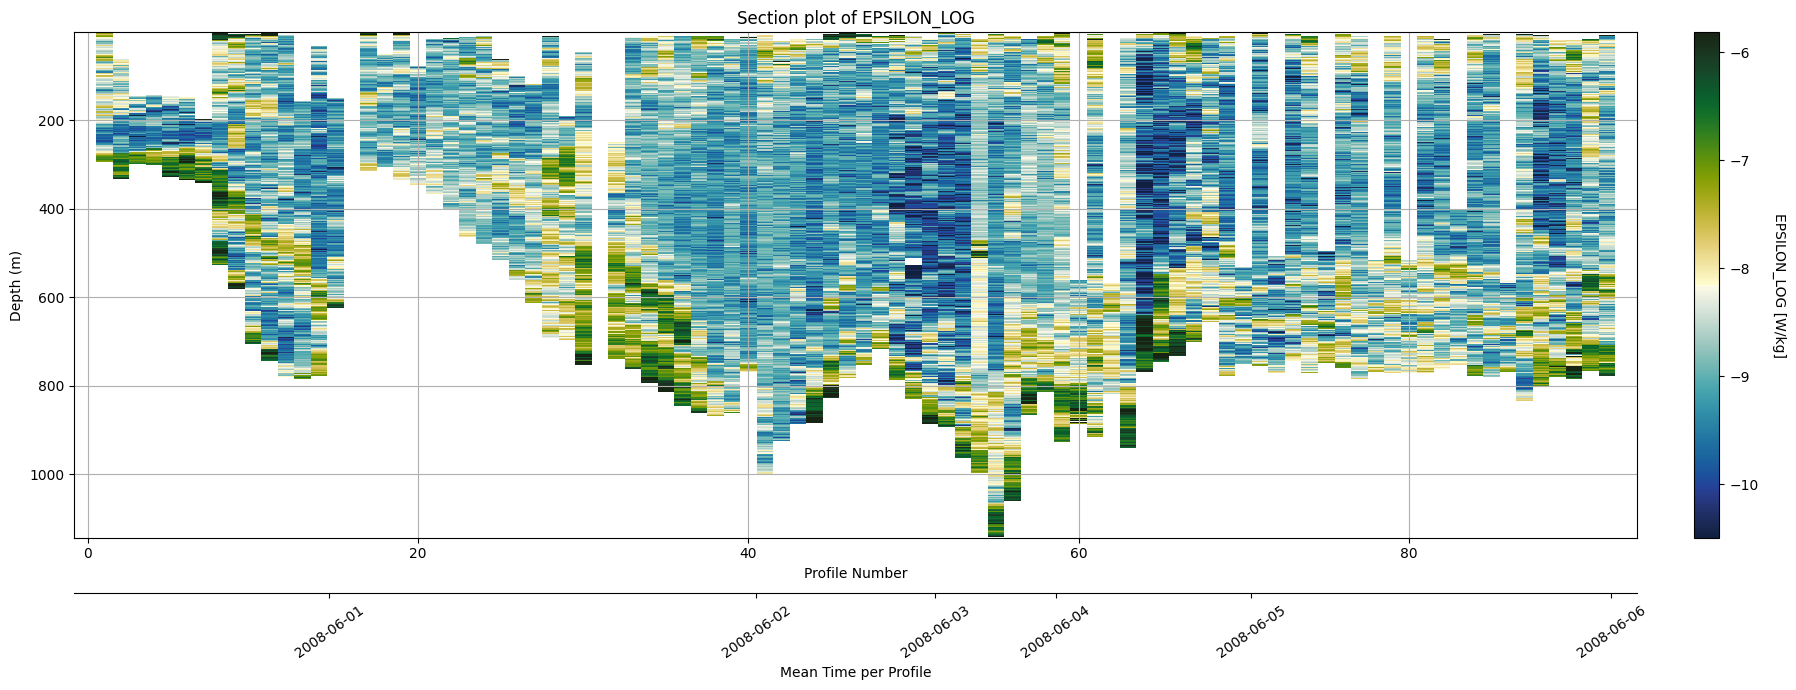

(<Figure size 2000x700 with 2 Axes>,
 [<Axes: title={'center': 'Section plot of EPSILON_LOG'}, xlabel='Profile Number', ylabel='Depth (m)'>])

In [151]:
start = 30
end = 50
start = None
end = None

plotting.plot_section(ds_flat, vars='EPSILON_LOG', v_res=1,start=start, end = end)

In [149]:
ds_flat['DISSIPATION_LEM'] = ds_flat['EPSILON']

In [150]:
importlib.reload(tools)
mean_ratio, median_ratio, ratio_total = tools.get_background_dissipation(ds_flat, profile_range=[34,48], depth_range=[200,500], sg005_ds=sg_005_ds)

NameError: name 'bg_yaml' is not defined

In [53]:
ds_sg005 = xr.open_dataset(mission_path + '/dissipation_binned.nc')

In [54]:
mask = (60 < ds_sg005.LATITUDE) & (ds_sg005.LATITUDE < 62) & (ds_sg005.TIME <= np.datetime64('2008-07-22T10:00')) & (ds_sg005.TIME >= np.datetime64('2008-06-06T20:00'))# & (ds_sg005.PROFILE_NUMBER%2 == 1)
ds_sg005 = ds_sg005.sel(TIME=mask)

In [55]:
latitudes = ds_sg005.LATITUDE.groupby(ds_sg005.PROFILE_NUMBER).mean().values
longitudes = ds_sg005.LONGITUDE.groupby(ds_sg005.PROFILE_NUMBER).mean().values
times = ds_sg005.TIME.groupby(ds_sg005.PROFILE_NUMBER).mean().values
profile_numbers = ds_sg005.PROFILE_NUMBER.groupby(ds_sg005.PROFILE_NUMBER).mean().values

In [56]:
len(profile_numbers)

293

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/3518551865.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar_glider.ax.set_yticklabels([
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/3518551865.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar_vmp.ax.set_yticklabels([


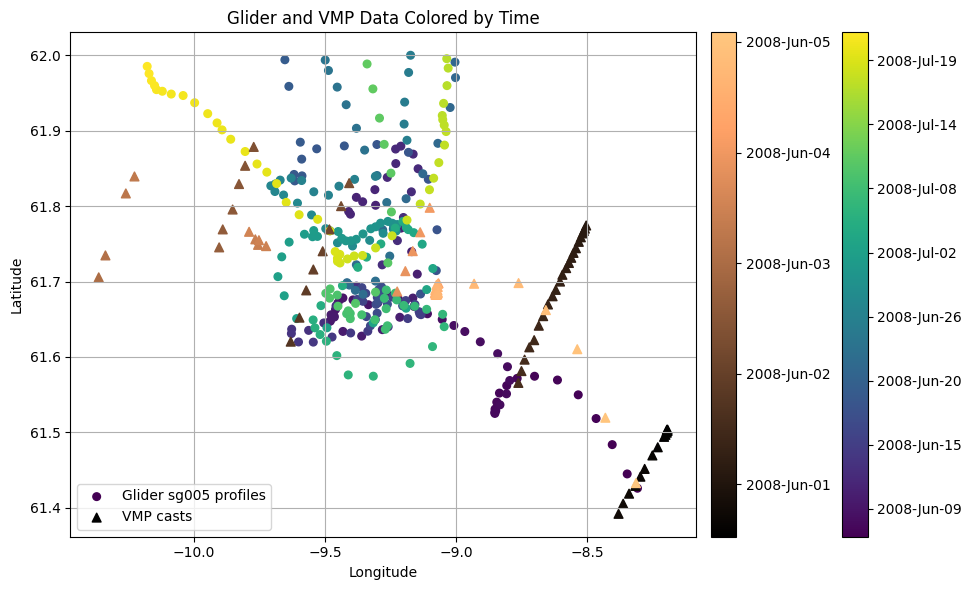

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# Set the colorbar mode: either 'TIME' or 'PROFILES'
color_mode = 'TIME'

# Prepare figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Data to plot
VMP_lat = ds_VMP.LATITUDE
VMP_lon = ds_VMP.LONGITUDE

if color_mode == 'TIME':
    # Convert times for plotting
    VMP_time = ds_VMP.TIME

    # Glider scatter
    #"""
    scatter_glider = ax.scatter(
        longitudes, latitudes, c=times,
        cmap='viridis', s=30, marker='o', label="Glider sg005 profiles"
    )
    cbar_glider = plt.colorbar(scatter_glider, ax=ax, pad=0.02, shrink=1)
    cbar_glider.ax.set_yticklabels([
        pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar_glider.get_ticks()
    ])
    #"""
    #"""
    # VMP scatter
    scatter_vmp = ax.scatter(
        VMP_lon, VMP_lat, c=VMP_time,
        cmap='copper', s=40, marker='^', label="VMP casts"
    )
    cbar_vmp = plt.colorbar(scatter_vmp, ax=ax, pad=0.02, shrink=1)
    cbar_vmp.ax.set_yticklabels([
        pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar_vmp.get_ticks()
    ])
    #"""

elif color_mode == 'PROFILES':
    # Use profile numbers instead of time
    VMP_cast = ds_VMP.CAST

    # Glider scatter
    scatter_glider = ax.scatter(
        longitudes, latitudes, c=profile_numbers,
        cmap='cool', s=30, marker='o', label="Glider sg005 profiles"
    )
    cbar_glider = plt.colorbar(scatter_glider, ax=ax, pad=0.02, shrink=1)
    cbar_glider.set_label("Glider Profile #")

    # VMP scatter
    scatter_vmp = ax.scatter(
        VMP_lon, VMP_lat, c=VMP_cast,
        cmap='copper_r', s=40, marker='^', label="VMP casts"
    )
    cbar_vmp = plt.colorbar(scatter_vmp, ax=ax, pad=0.02, shrink=1)
    cbar_vmp.set_label("VMP Cast #")

# Final plot settings
ax.legend(loc='lower left')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Glider and VMP Data Colored by " + color_mode.title())

plt.tight_layout()
plt.grid()
plt.show()



In [58]:
ds_sg005

<xarray.Dataset> Size: 16MB
Dimensions:                     (TIME: 122534)
Coordinates:
  * TIME                        (TIME) datetime64[ns] 980kB 2008-06-06T20:00:...
Data variables: (12/15)
    PROFILE_NUMBER              (TIME) float64 980kB ...
    DEPTH                       (TIME) float64 980kB ...
    PSAL                        (TIME) float64 980kB ...
    VELOCITY_SCALE_2_LOG        (TIME) float64 980kB ...
    VERTICAL_WATER_VELOCITY     (TIME) float64 980kB ...
    VERTICAL_WATER_VELOCITY_HP  (TIME) float64 980kB ...
    ...                          ...
    PRES                        (TIME) float64 980kB ...
    VELOCITY_SCALE              (TIME) float64 980kB ...
    SORTED_N2                   (TIME) float64 980kB ...
    ALPHA_1                     (TIME) float64 980kB ...
    DISSIPATION_LEM             (TIME) float64 980kB ...
    DISSIPATION_LEM_LOG         (TIME) float64 980kB ...
Attributes: (12/44)
    title:                                      OceanGliders trajectory file
    id:                                         sg005_20080606T180738_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    disclaimer:                                 Data provided AS-IS.
    Glider:                                     005
    Mission:                                    20080606
    binning:                                    mean of each profile
    binning_method:                             mean
    c_epsilon:                                  0.37

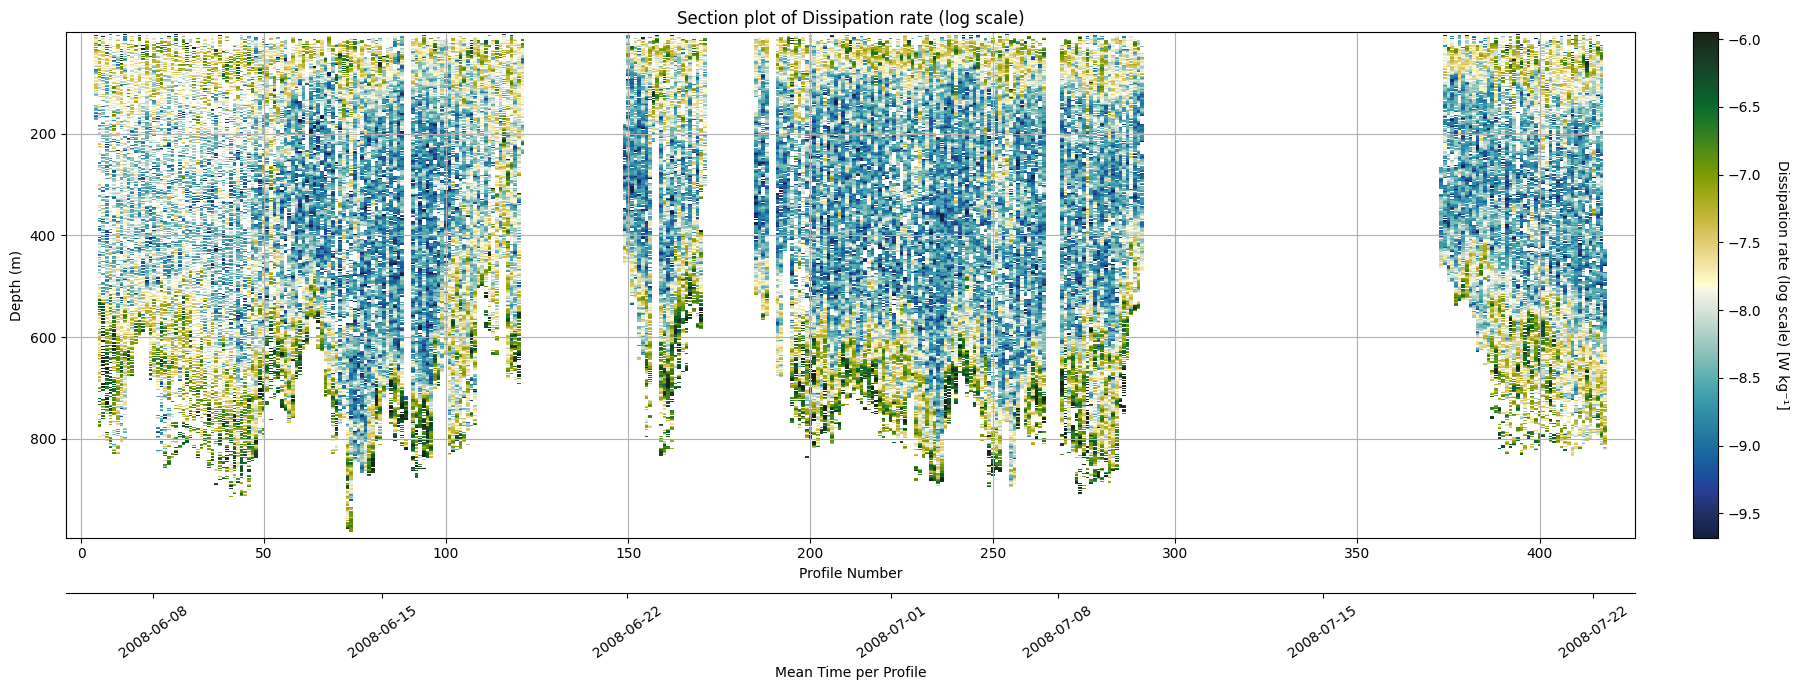

(<Figure size 2000x700 with 2 Axes>,
 [<Axes: title={'center': 'Section plot of Dissipation rate (log scale)'}, xlabel='Profile Number', ylabel='Depth (m)'>])

In [59]:
plotting.plot_section(ds_sg005,vars = ['DISSIPATION_LEM_LOG'])

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/3575999051.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([


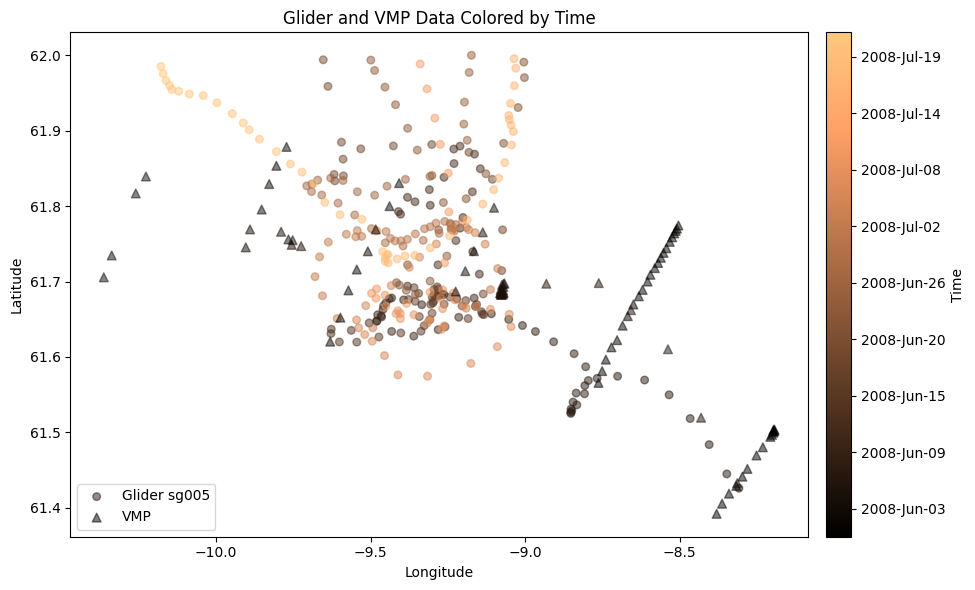

In [60]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Choose colorbar mode: 'TIME' or 'PROFILES'
color_mode = 'TIME'

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Data
VMP_lat = ds_VMP.LATITUDE
VMP_lon = ds_VMP.LONGITUDE

if color_mode == 'TIME':
    # Combine times from both sources and normalize
    all_times = np.concatenate([times, ds_VMP.TIME])
    norm = mcolors.Normalize(vmin=min(all_times), vmax=max(all_times))
    cmap = 'copper'

    # Plot glider (circles)
    ax.scatter(
        longitudes, latitudes, c=times,
        cmap=cmap, norm=norm, s=30, marker='o', label="Glider sg005", alpha  = 0.5
    )

    # Plot VMP (triangles)
    ax.scatter(
        VMP_lon, VMP_lat, c=ds_VMP.TIME,
        cmap=cmap, norm=norm, s=40, marker='^', label="VMP", alpha  = 0.5
    )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1)
    cbar.ax.set_yticklabels([
        pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()
    ])
    cbar.set_label("Time")

elif color_mode == 'PROFILES':
    # Combine profile/cast numbers and normalize
    all_profiles = np.concatenate([profile_numbers, ds_VMP.CAST])
    norm = mcolors.Normalize(vmin=min(all_profiles), vmax=max(all_profiles))
    cmap = 'plasma'

    # Plot glider (circles)
    ax.scatter(
        longitudes, latitudes, c=profile_numbers,
        cmap=cmap, norm=norm, s=30, marker='o', label="Glider sg005", alpha = 2
    )

    # Plot VMP (triangles)
    ax.scatter(
        VMP_lon, VMP_lat, c=ds_VMP.CAST,
        cmap=cmap, norm=norm, s=40, marker='^', label="VMP", alpha = 2
    )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1)
    cbar.set_label("Profile/Cast Number")

# Final plot touches
ax.legend(loc='lower left')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Glider and VMP Data Colored by {color_mode.title()}")

plt.tight_layout()
plt.show()


In [61]:
def plot_hist(ds, median=None, mean=None, color='blue', vars=['DISSIPATION_LEM'], ax = None, label = ""):
        figh, axh = plotting.plot_histogram(
            ds, vars=vars, bins=50, log_scale=True, density=True,
            alpha=0.2, color=color, edgecolor='black', ax=ax
        )
        unit = utilities.get_unit(ds, vars[0])
        if mean is not None:
            ax.axvline(np.log10(mean), color=color, linestyle='--', label=f'{label} Mean = {mean:.2e} [{unit}]')
        if median is not None:
            ax.axvline(np.log10(median), color=color, linestyle=':', label=f'{label} Median = {median:.2e} [{unit}]')
        #ax.set_title(f'Background Dissipation Histogram of sg{ds.Glider +'/'+ ds.Mission} (c = {ds.c_epsilon})')
        ax.legend()
        return ax

In [65]:
mask = (ds_sg005.DEPTH < 150) & (ds_sg005.DEPTH > 20)
ds_sg005_hist = ds_sg005.sel(TIME = mask)
ds_VMP_hist = ds_VMP.where(ds_VMP.DEPTH < 150, drop=True)
ds_VMP_hist = ds_VMP_hist.where(ds_VMP_hist.DEPTH > 20, drop= True)

In [68]:
time_max_sg005 = "2008-07-22"
lat_range = [60, 61.9]
min_depth = 0
max_depth = 200

msk_sg005 = (lat_range[0] < ds_sg005.LATITUDE) & (ds_sg005.LATITUDE < lat_range[1]) & (ds_sg005.TIME <= np.datetime64(time_max_sg005)) & (ds_sg005.DEPTH < max_depth) & (ds_sg005.DEPTH > min_depth)
ds_sg005_hist = ds_sg005.sel(TIME=mask)

ds_VMP_hist = ds_VMP.where(ds_VMP.DEPTH < max_depth, drop=True)
ds_VMP_hist = ds_VMP_hist.where(ds_VMP_hist.DEPTH > min_depth, drop= True)

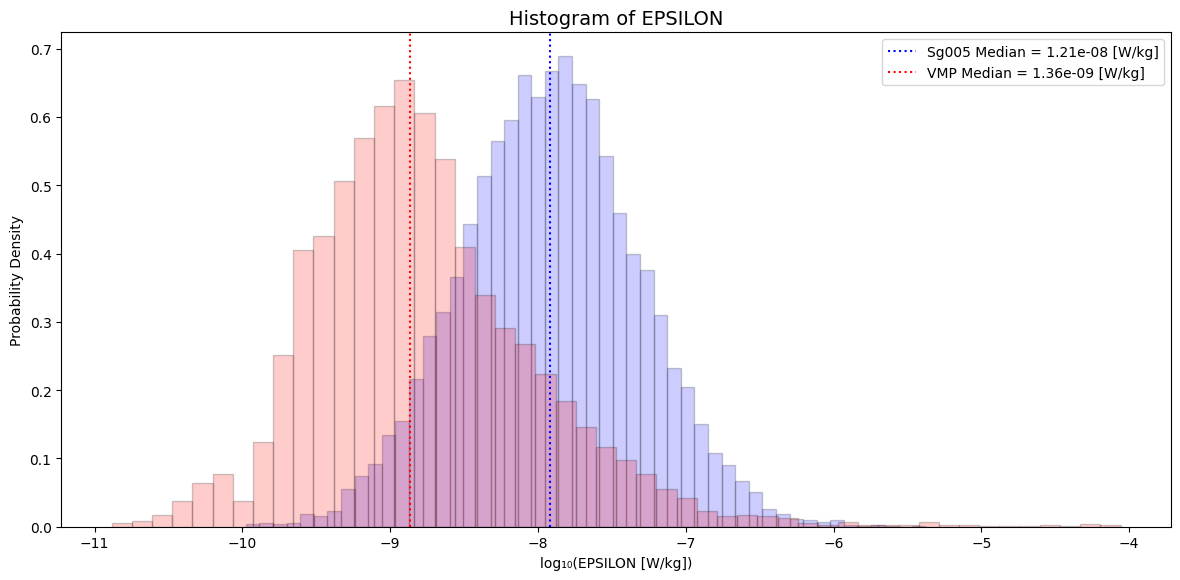

In [69]:
fig, ax = plt.subplots(figsize = [12,6])
median_sg005 = np.nanmedian(ds_sg005_hist.DISSIPATION_LEM)
median_VMP = np.nanmedian(ds_VMP_hist.EPSILON)
ax = plot_hist(ds = ds_sg005_hist, ax=ax, median=median_sg005, label = "Sg005")
ax = plot_hist(ds = ds_VMP_hist, vars=['EPSILON'], ax=ax, median=median_VMP, color='red', label = "VMP")

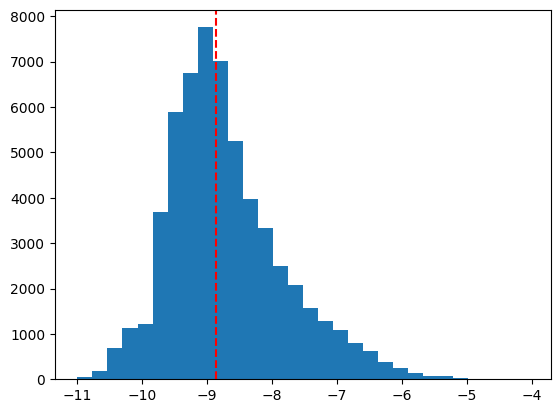

In [203]:
epsilon = ds.EPSILON.values.flatten()
epsilon = epsilon[~np.isnan(epsilon)]
median_epsilon = np.median(epsilon)
log_epsilon = np.log10(epsilon)
median_log = np.log10(median_epsilon)

plt.hist(log_epsilon, log = False, bins = 30)
plt.axvline(median_log,0,10000, color = 'red', linestyle = '--')

np.float64(-8.86669978609232)

### 3. Investigate surface conditions for the period of VMP and sg005

In [9]:
ERA5_basepath = '/Users/tillmoritz/Desktop/Master_thesis/Data/ERA-5/'

In [70]:
ds_ERA5 = xr.open_dataset(ERA5_basepath + '/ERA5_all_winds_fluxes_waves.nc')

In [71]:
ds_ERA5

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 27024, latitude: 21, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 216kB 2006-11-01 ... 2009-11-30T2...
  * latitude    (latitude) float64 168B 60.0 60.25 60.5 ... 64.5 64.75 65.0
  * longitude   (longitude) float64 392B -15.0 -14.75 -14.5 ... -3.5 -3.25 -3.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 111MB ...
    slhf        (valid_time, latitude, longitude) float32 111MB ...
    ssr         (valid_time, latitude, longitude) float32 111MB ...
    str         (valid_time, latitude, longitude) float32 111MB ...
    sshf        (valid_time, latitude, longitude) float32 111MB ...
    e           (valid_time, latitude, longitude) float32 111MB ...
    u10         (valid_time, latitude, longitude) float32 111MB ...
    v10         (valid_time, latitude, longitude) float32 111MB ...
    zust        (valid_time, latitude, longitude) float32 111MB ...
    swh         (valid_time, latitude, longitude) float32 111MB ...
    pp1d        (valid_time, latitude, longitude) float32 111MB ...
    TAU         (valid_time, latitude, longitude) float32 111MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-31T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [118]:
importlib.reload(utilities)

<module 'dissipationSML.utilities' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/utilities.py'>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_ERA5_at_time(ds, time, variable):
    """
    Plots wind vectors (u10, v10) if variable is 'wind', 
    otherwise plots the chosen variable as colored markers with a colorbar.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing at least 'u10' and 'v10' for wind.
    time : str or pandas.Timestamp
        The time point for which data should be plotted.
    variable: str
        Variable to be plotted on the map. 
        Use 'wind' for quiver plot, or any other variable name for marker plot.

    Returns
    -------
    fig, ax : matplotlib figure and axis
    """
    # Select data for the specified time
    ds_at_time = ds.sel(valid_time=time)

    # Extract coordinates
    latitudes = ds['latitude'].values
    longitudes = ds['longitude'].values
    lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([longitudes.min()-1, longitudes.max()+1, latitudes.min()-1, latitudes.max()+1], 
                  crs=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.LAND, edgecolor='black')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    cmap = utilities.get_colormap(variable)
    label = utilities.get_label(variable)

    # Plot based on variable type
    if variable.lower() == 'wind':
        # Extract wind components
        u = ds_at_time['u10'].values
        v = ds_at_time['v10'].values

        # Reshape if needed
        if u.ndim == 1:
            u = u.reshape(len(latitudes), len(longitudes))
            v = v.reshape(len(latitudes), len(longitudes))

        # Compute wind speed
        speed = np.sqrt(u**2 + v**2)

        unit = utilities.get_unit(ds,'u10')

        step = 1  # Downsample for clarity
        q = ax.quiver(
            lon_grid[::step, ::step], lat_grid[::step, ::step],
            u[::step, ::step], v[::step, ::step],
            speed[::step, ::step],  # Color by speed
            cmap=cmap, transform=ccrs.PlateCarree(), scale=1000
        )

        # Add colorbar for speed
        cbar = plt.colorbar(q, ax=ax, orientation='vertical', shrink=0.7)
        cbar.set_label(f"{label} ({unit})")

        ax.set_title(f"Wind Vectors at {time}")

    else:
        if variable not in ds.data_vars:
            raise ValueError(f"Variable '{variable}' not found in dataset.")
        
        norm = None
        if variable in ['ssr','slhf','str','sshf']:
            norm = mpl.colors.Normalize(vmin=-700, vmax=700)

        data = ds_at_time[variable].values
        sc = ax.scatter(lon_grid, lat_grid, c=data, cmap=cmap, 
                        transform=ccrs.PlateCarree(), marker='o',norm=norm)
        
        unit = utilities.get_unit(ds, variable)
        cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7)
        cbar.set_label(f"{label} ({unit})")
        ax.set_title(f"{label} at {time}")

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    plt.show()
    return fig, ax


In [126]:
ds_ERA5

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 27024, latitude: 21, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 216kB 2006-11-01 ... 2009-11-30T2...
  * latitude    (latitude) float64 168B 60.0 60.25 60.5 ... 64.5 64.75 65.0
  * longitude   (longitude) float64 392B -15.0 -14.75 -14.5 ... -3.5 -3.25 -3.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 111MB ...
    slhf        (valid_time, latitude, longitude) float32 111MB ...
    ssr         (valid_time, latitude, longitude) float32 111MB ...
    str         (valid_time, latitude, longitude) float32 111MB ...
    sshf        (valid_time, latitude, longitude) float32 111MB ...
    e           (valid_time, latitude, longitude) float32 111MB ...
    u10         (valid_time, latitude, longitude) float32 111MB ...
    v10         (valid_time, latitude, longitude) float32 111MB ...
    zust        (valid_time, latitude, longitude) float32 111MB ...
    swh         (valid_time, latitude, longitude) float32 111MB ...
    pp1d        (valid_time, latitude, longitude) float32 111MB ...
    TAU         (valid_time, latitude, longitude) float32 111MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-31T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [11]:
ds_ERA5 = ds_ERA5.sel(valid_time = slice('2008-06-01','2008-08-01'))

In [46]:
times = ds_ERA5.valid_time.values
time_bar = widgets.SelectionSlider(options=times,index=0)
var_options = ['wind'] + [var for var in ds_ERA5.data_vars if ds_ERA5[var].dtype.kind in {'i', 'f'}]
var_dropdown = widgets.Dropdown(options=var_options, value=var_options[0], description="Variable:")

ui = widgets.VBox([widgets.Label("Select time:"), time_bar,
                       widgets.Label("Select variable:"),var_dropdown])

def interactive_ERA5(time, variable):
    plot_ERA5_at_time(ds_ERA5,time= time,variable= variable)

# Create interactive plot
out = widgets.interactive_output(interactive_ERA5, {
        'time': time_bar,
        'variable': var_dropdown,})

display(ui,out)

Output()

In [15]:
ds_ERA5 = ds_ERA5.sel(valid_time = slice('2008-06-01','2008-07-01'))

In [16]:
ds_ERA5_10W = ds_ERA5.sel(longitude = -10)
ds_ERA5_63N = ds_ERA5.sel(latitude = 63)

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/3460446555.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


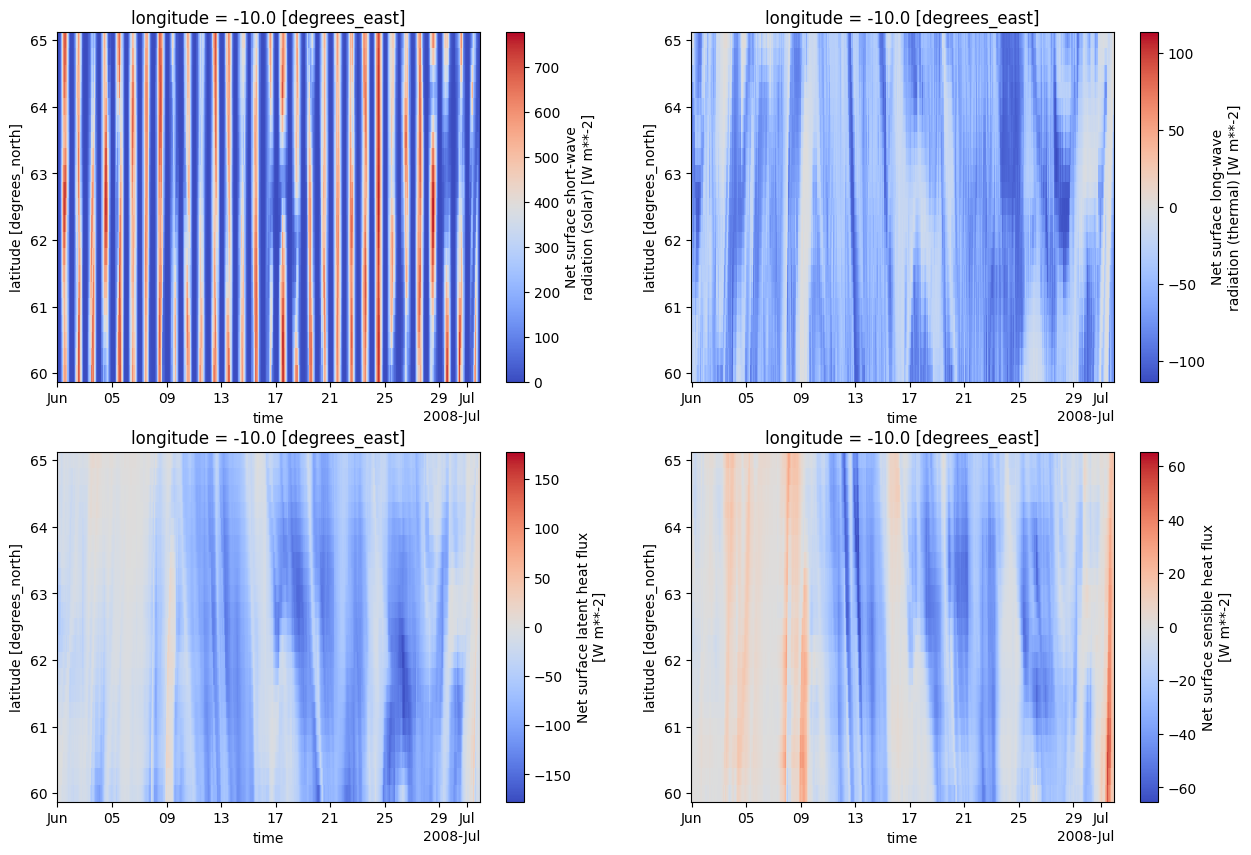

In [17]:
import cmocean.cm as cmo#
import matplotlib.cm as cm

fig, axs = plt.subplots(nrows=2, ncols=2,figsize = [15,10])
norm = None #mpl.colors.Normalize(vmin=-700, vmax=700)
cmap = cm.get_cmap('coolwarm')
ds_ERA5_10W['ssr'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[0][0])
ds_ERA5_10W['str'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[0][1])
ds_ERA5_10W['slhf'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[1][0])
ds_ERA5_10W['sshf'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[1][1])

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/2125844742.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


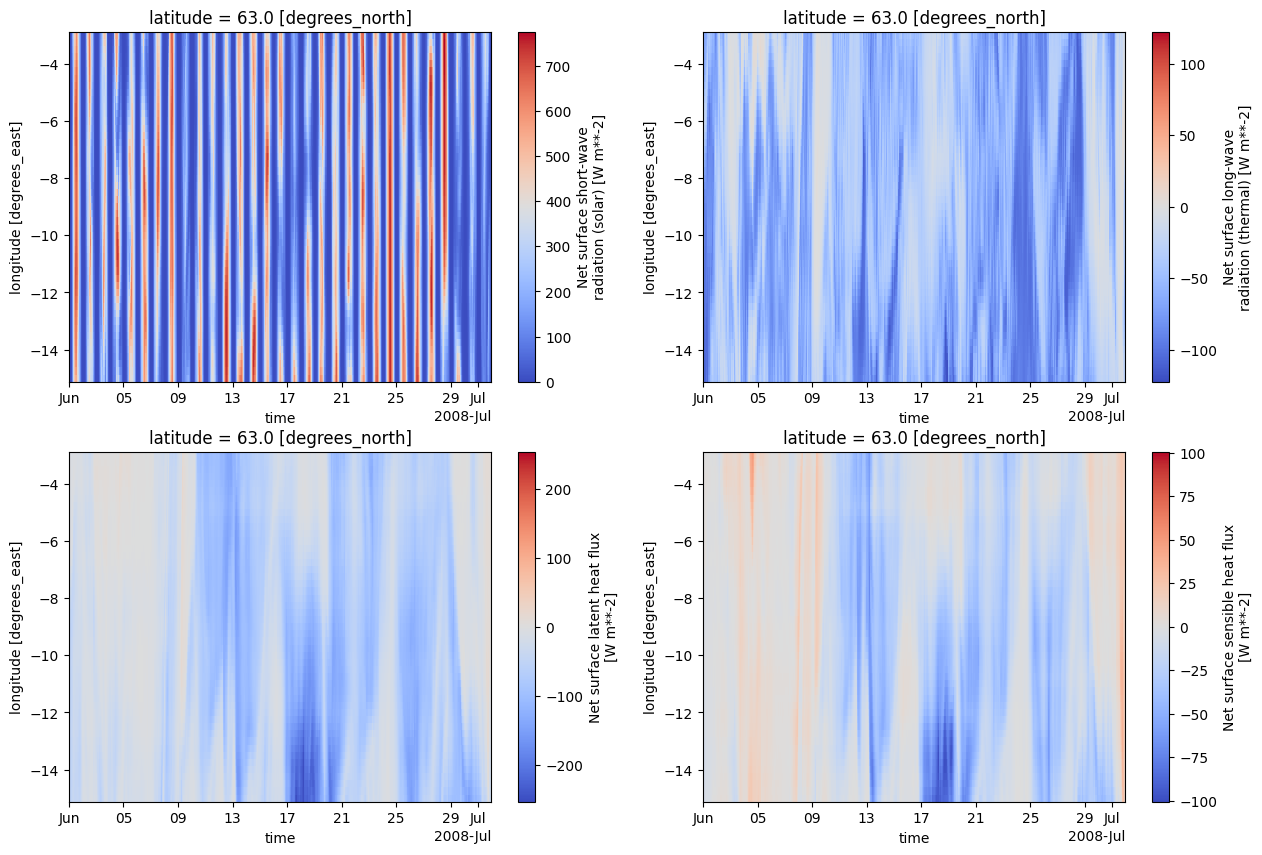

In [18]:
fig, axs = plt.subplots(nrows=2, ncols=2,figsize = [15,10])
norm = None #mpl.colors.Normalize(vmin=-700, vmax=700)
cmap = cm.get_cmap('coolwarm')
ds_ERA5_63N['ssr'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[0][0])
ds_ERA5_63N['str'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[0][1])
ds_ERA5_63N['slhf'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[1][0])
ds_ERA5_63N['sshf'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[1][1])

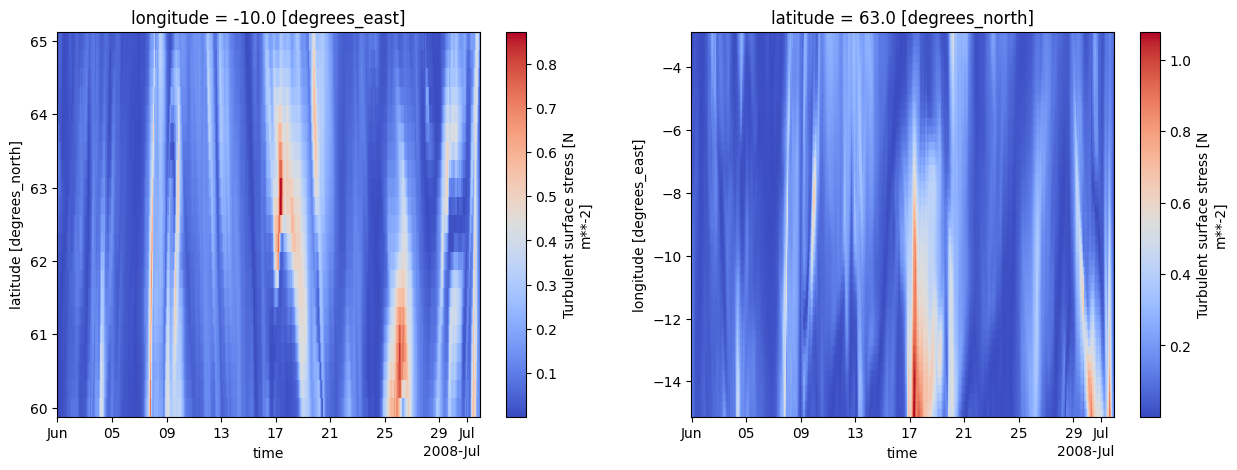

In [19]:
Tau_10W = ds_ERA5.sel(longitude = -10)
Tau_63N = ds_ERA5.sel(latitude = 63)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize = [15,5])
Tau_10W['TAU'].plot(x='valid_time',y='latitude',cmap=cmap, ax = axs[0])
Tau_63N['TAU'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[1])

In [77]:
def match_era5_to_mld(ds_mld, ds_era5, lon_range=None, lat_range=None, time_lag = None, time_range = None):
    """
    Match ERA5 data to MLD observations based on time, longitude, and latitude. 
    ERA5 values are averaged over a spatial range (if provided) and matched by nearest time.

    Parameters
    ----------
    ds_mld : xarray.Dataset
        Dataset with MLD observations and variables: TIME, LATITUDE, LONGITUDE.
    ds_era5 : xarray.Dataset
        ERA5 dataset with dimensions: valid_time, latitude, longitude.
    lon_range : float or None, optional
        Longitude range (in degrees) for spatial averaging. If None, uses nearest longitude.
    lat_range : float or None, optional
        Latitude range (in degrees) for spatial averaging. If None, uses nearest latitude.
    time_lag: float
        Take the profile time minus a time_lag [hours] for the matching of the ERA5 data.
    time_range: float
        Takes a time range [hours], in which the ERA5 data is averaged.

    Returns
    -------
    xarray.Dataset
        MLD dataset with ERA5 variables added as 1D arrays aligned with TIME.
    """
    times = ds_mld.TIME.values
    lons = ds_mld.LONGITUDE.values
    lats = ds_mld.LATITUDE.values

    if time_lag:
        times = times - np.timedelta64(time_lag,"h")

    matched_profiles = []

    for i in tqdm(range(len(times)), desc="Matching ERA5 to MLD"):
        time = times[i]
        lon = lons[i]
        lat = lats[i]

        if time_range:
            match = ds_era5.sel(valid_time=slice(time, time+np.timedelta64(time_range,'h')))
        else:
            # Select nearest ERA5 time
            match = ds_era5.sel(valid_time=time, method="nearest")

        # Apply spatial window if specified
        if lon_range:
            match = match.sel(longitude=slice(lon - lon_range, lon + lon_range))
        else:
            match = match.sel(longitude=slice(lon))

        if lat_range:
            match = match.sel(latitude=slice(lat - lat_range, lat + lat_range))
        else:
            match = match.sel(latitude=slice(lat))

        # Compute spatial mean and assign timestamp
        match = match.mean(dim=["latitude", "longitude"], skipna=True, keep_attrs=True)
        match = match.assign_coords(TIME=time)
        matched_profiles.append(match)

    # Combine matched ERA5 profiles into one dataset
    ds_matched = xr.concat(matched_profiles, dim="TIME")

    # Merge new ERA5 variables into the MLD dataset
    for var in ds_era5.data_vars:
        if var not in ds_mld:
            ds_mld[var] = ds_matched[var]

    # Store matching settings as metadata
    ds_mld.attrs["longitude_range_used"] = f"±{lon_range}°" if lon_range else "Nearest longitude"
    ds_mld.attrs["latitude_range_used"] = f"±{lat_range}°" if lat_range else "Nearest latitude"
    ds_mld.attrs["time_lag"] = f"{time_lag} hours" if time_lag else "Nearest point in time"

    return ds_mld

In [73]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [74]:
mld = tools.compute_mld(ds, variable ='SIGMA_T')

In [75]:
ds_mld = utilities.df_to_ds(mld, folder = mission_path, glider_name= mission_path)

In [79]:
ds_ERA5

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 27024, latitude: 21, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 216kB 2006-11-01 ... 2009-11-30T2...
  * latitude    (latitude) float64 168B 60.0 60.25 60.5 ... 64.5 64.75 65.0
  * longitude   (longitude) float64 392B -15.0 -14.75 -14.5 ... -3.5 -3.25 -3.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 111MB ...
    slhf        (valid_time, latitude, longitude) float32 111MB ...
    ssr         (valid_time, latitude, longitude) float32 111MB ...
    str         (valid_time, latitude, longitude) float32 111MB ...
    sshf        (valid_time, latitude, longitude) float32 111MB ...
    e           (valid_time, latitude, longitude) float32 111MB ...
    u10         (valid_time, latitude, longitude) float32 111MB ...
    v10         (valid_time, latitude, longitude) float32 111MB ...
    zust        (valid_time, latitude, longitude) float32 111MB ...
    swh         (valid_time, latitude, longitude) float32 111MB ...
    pp1d        (valid_time, latitude, longitude) float32 111MB ...
    TAU         (valid_time, latitude, longitude) float32 111MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-31T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [82]:
ds_mld = match_era5_to_mld(ds_mld, ds_ERA5, lon_range=0.25, lat_range=0.25, time_lag=5, time_range=5)

Matching ERA5 to MLD:   0%|          | 0/770 [00:00<?, ?it/s]

Matching ERA5 to MLD: 100%|██████████| 770/770 [00:04<00:00, 182.97it/s]


In [83]:
ds_mld

<xarray.Dataset> Size: 80kB
Dimensions:         (TIME: 770)
Coordinates:
  * TIME            (TIME) datetime64[ns] 6kB 2008-06-06T18:12:00 ... 2008-08...
Data variables: (12/18)
    PROFILE_NUMBER  (TIME) float64 6kB 1.0 2.0 3.0 4.0 ... 770.0 771.0 772.0
    MLD             (TIME) float64 6kB 20.4 20.0 20.2 21.7 ... 20.0 20.1 20.6
    LONGITUDE       (TIME) float64 6kB -8.275 -8.276 -8.286 ... -6.061 -6.052
    LATITUDE        (TIME) float64 6kB 61.42 61.42 61.42 ... 63.66 63.69 63.69
    MISSION         (TIME) object 6kB '/Users/tillmoritz/Desktop/Master_thesi...
    GLIDER          (TIME) object 6kB '/Users/tillmoritz/Desktop/Master_thesi...
    ...              ...
    u10             (TIME) float32 3kB nan nan nan nan nan ... nan nan nan nan
    v10             (TIME) float32 3kB nan nan nan nan nan ... nan nan nan nan
    zust            (TIME) float32 3kB nan nan nan nan nan ... nan nan nan nan
    swh             (TIME) float32 3kB nan nan nan nan nan ... nan nan nan nan
    pp1d            (TIME) float32 3kB nan nan nan nan nan ... nan nan nan nan
    TAU             (TIME) float32 3kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    longitude_range_used:  ±0.25°
    latitude_range_used:   ±0.25°
    time_lag:              5 hours